In [1]:
# Student Performance Analysis
# Goal: Analyze factors affecting student grades using visualization and correlation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

def load_exam(data_path=r"C:\Users\nooth\Downloads"):
    csv_path = os.path.join(data_path,"student-por")
    return pd.read_csv(csv_path)

(649, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  

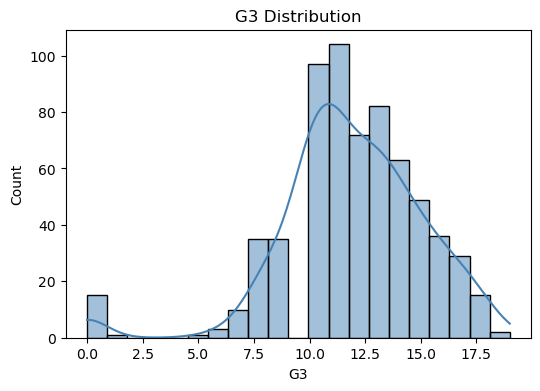

<Axes: >

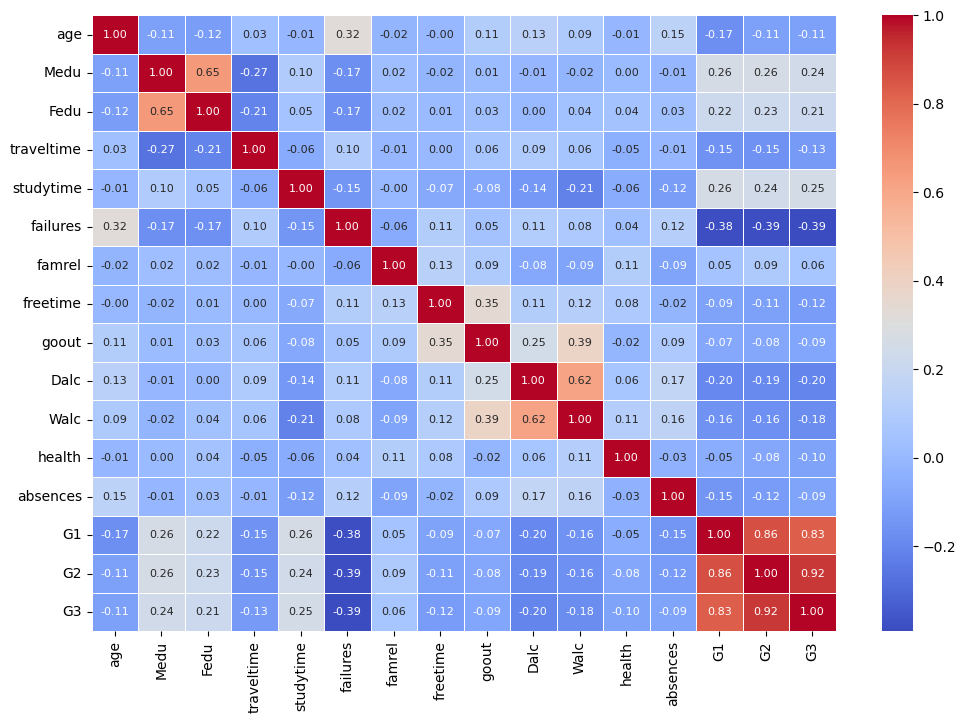

In [2]:
df = pd.read_csv("C:/Users/nooth/Downloads/archive (10)/student-por.csv")
df.head()
print(df.shape)# Check dataset dimensions (rows, columns)
print(df.info())
print(df.describe())
print(df.isnull().sum())#to check missing values

plt.figure(figsize=(6,4))
sns.histplot(df['G3'], kde=True, color='steelblue')# Histogram to understand G3 distribution
plt.title('G3 Distribution')
plt.show()
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation = numeric_df.corr()
plt.figure(figsize=(12, 8))
# Heatmap to visualize relationships between variables
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5, annot_kws={"size":8})

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
X = df.drop('G3', axis=1)
y = df['G3']
# to identify categorical and numerical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include='number').columns.tolist()
print("Categorical:", cat_cols)
print("Numerical:", num_cols)
#to fill the missing values and convert categorical variables to numeric variables using one-hot encoding
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
#to fill mssing values and scale features using standard normal distribution
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
#combining both pipelines
preprocessor = ColumnTransformer([
    ('cat', cat_pipeline, cat_cols),
    ('num', num_pipeline, num_cols)
])

Categorical: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Numerical: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']


In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
# Apply preprocessing pipeline (encoding + scaling) to features
X_temp = preprocessor.fit_transform(X)
#here we are intializng random forest model
rf_temp = RandomForestRegressor(n_estimators=50, random_state=42)
rf_temp.fit(X_temp, y)
print("Feature Importances:", rf_temp.feature_importances_)

Feature Importances: [3.19414633e-03 3.74234558e-03 1.09060460e-03 1.48183853e-03
 8.04897718e-04 5.52394896e-04 7.74482691e-04 5.53183051e-04
 2.25290422e-04 2.26891915e-04 4.48512102e-04 5.23274335e-04
 2.58929066e-03 1.15557942e-03 2.78520271e-03 5.57286232e-04
 2.93781210e-04 1.46137295e-03 1.99271683e-03 2.59610258e-04
 3.97341065e-03 1.23639142e-03 5.05880681e-03 7.51336799e-04
 2.13816273e-03 5.77576479e-04 6.18478538e-04 6.06956359e-04
 1.25500859e-03 2.52262614e-03 1.16411672e-03 5.41722740e-04
 4.54408990e-04 9.16517279e-04 9.31818408e-04 4.44183488e-04
 8.19353432e-04 5.21071286e-04 3.90945785e-04 2.49585238e-04
 2.83058346e-04 1.56508188e-03 1.29749988e-03 6.42555514e-03
 6.74703443e-03 2.65420632e-03 4.67522849e-03 2.62368717e-03
 4.60365749e-03 1.21421033e-02 5.64104459e-03 6.18658445e-03
 4.44370822e-03 5.11438772e-03 6.34997329e-03 3.23565057e-02
 1.26243511e-02 8.34381152e-01]


In [5]:
from sklearn.model_selection import train_test_split
#here we are sptilling data for training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train size:", X_train.shape, "| Test size:", X_test.shape)

Train size: (519, 32) | Test size: (130, 32)


In [6]:
from sklearn.model_selection import GridSearchCV
#here we are creating full pipeline which includes preprocessing and model training
full_pipeline = Pipeline([('preprocessor', preprocessor),('model', RandomForestRegressor(random_state=42))])
#to find no.of trees in forest and depth of each tree
param_grid = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [None, 5, 10],}
# this Performs Grid Search with Cross Validation
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)
print("Best Params:", grid_search.best_params_)
print("Best CV R2:", round(grid_search.best_score_, 4))

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Params: {'model__max_depth': 5, 'model__n_estimators': 100}
Best CV R2: 0.8461


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
#to get the best trained model from GridSearch
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("MAE :", round(mean_absolute_error(y_test, y_pred), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 4))
print("R2  :", round(r2_score(y_test, y_pred), 4))
# Lower MAE and RMSE indicate better model accuracy
# Higher R² indicates better explanatory power of the model

MAE : 0.7145
RMSE: 1.2112
R2  : 0.8496


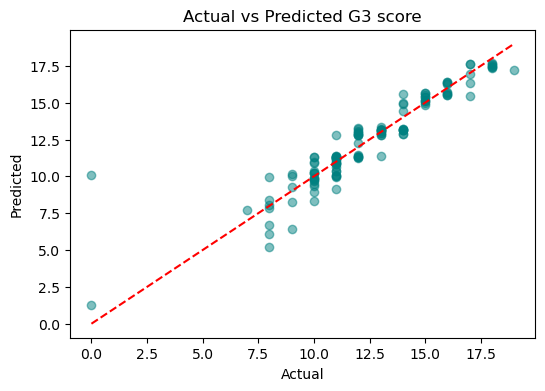

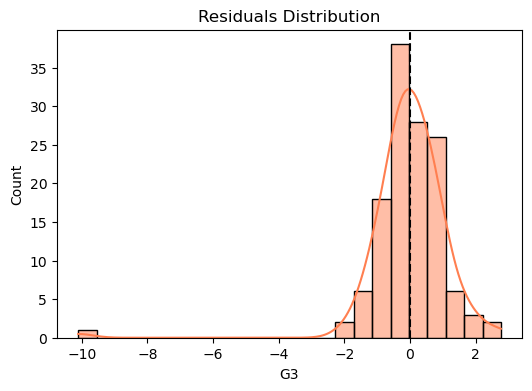

In [8]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted G3 score')
plt.show()

residuals = y_test - y_pred
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True, color='coral')
plt.title('Residuals Distribution')
plt.axvline(0, color='black', linestyle='--')
plt.show()

In [10]:
import pickle

with open('student_rf_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Model saved as student_rf_model.pkl")



Model saved as student_rf_model.pkl
